In [1]:
print("Hello, codeAlpha!")

Hello, codeAlpha!


In [2]:
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Add target number
df["target"] = iris.target

# Add flower species names
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# Check the size of the dataset
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 6)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [5]:
# Count the number of flowers in each species
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


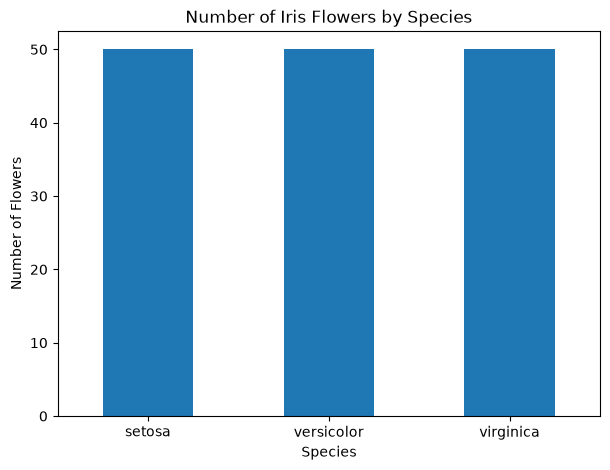

In [8]:
# Visualize the number of flowers in each species
df["species"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Number of Iris Flowers by Species")
plt.xlabel("Species")
plt.ylabel("Number of Flowers")
plt.xticks(rotation=0)
plt.show()

In [7]:
import matplotlib.pyplot as plt


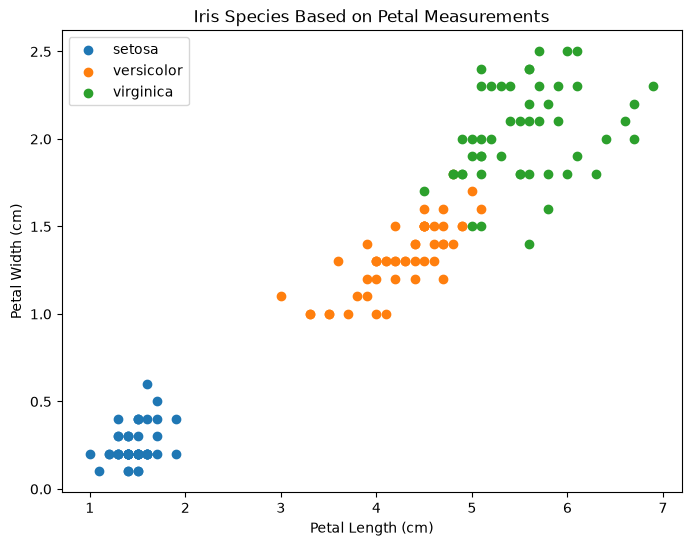

In [9]:
# Scatter plot of petal length vs petal width

plt.figure(figsize=(8, 6))

for species in df["species"].unique():
    species_data = df[df["species"] == species]
    
    plt.scatter(
        species_data["petal length (cm)"],
        species_data["petal width (cm)"],
        label=species
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Species Based on Petal Measurements")
plt.legend()
plt.show()

In [10]:
# Select input features
X = df[iris.feature_names]

# Select target
y = df["target"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [14]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1 Score  : 0.9333


In [16]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



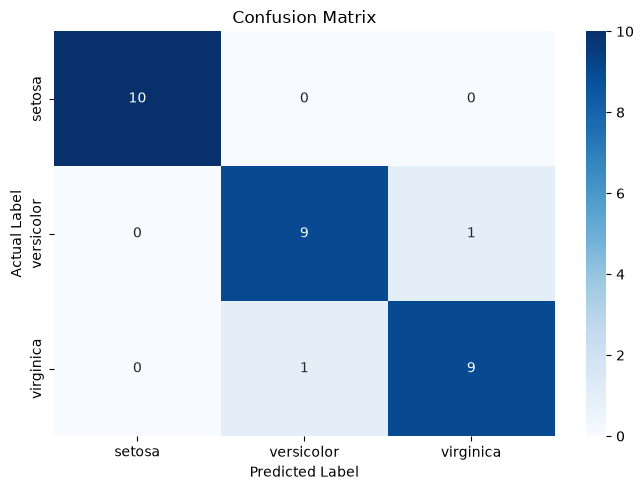

Confusion matrix saved successfully!


In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

print("Confusion matrix saved successfully!")




In [19]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Flower Species:", predicted_species)

Predicted Flower Species: setosa


In [22]:
import os

print(os.getcwd())
print(os.path.exists("../images"))

/Users/akshaychaudhari/Desktop/CodeAlpha_Iris_Classification/notebook
False


In [23]:
import os

os.makedirs("../images", exist_ok=True)

print("Images folder ready!")

Images folder ready!
